In [1]:
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

In [2]:
df = pd.read_csv("philippines_gdp_quarterly.csv")

t      = df["Time_Index"].values.astype(float)
y      = df["GDP"].values.astype(float)
n      = len(t)
labels = df["Period"].values

# tick positions: roughly every 4 years (16 quarters)
tick_idx = np.arange(0, n, 16)

print(f"Loaded {n} data points  ({labels[0]} – {labels[-1]})")
df.head()

Loaded 172 data points  (1981_Q1 – 2023_Q4)


,Period,Time_Index,Household_Final_Consumption,Government_Final_Consumption,Gross_Capital_Formation,Exports,Imports,Statistical_Discrepancy,GDP
0,1981_Q1,1,42128.233683,6187.253140,19929.566381,13627.328553,13794.798227,8234.116117,76311.699648
1,1981_Q2,2,47703.160331,6774.334021,21486.970942,12821.132173,15773.357998,7238.703786,80250.943255
2,1981_Q3,3,49102.827280,6565.463135,20044.562840,12131.919869,16383.938599,4248.212006,75709.046531
3,1981_Q4,4,56748.085076,7002.780804,23004.244257,13109.861815,15199.823776,2994.159681,87659.307856
4,1982_Q1,5,47972.872582,7489.600131,25305.646848,12113.192210,15930.787614,7905.606113,84856.130271


In [3]:
m = n - 2   # number of interior knots = 358

# right-hand side: finite-difference second-derivative estimate at each knot
b_rhs = np.array([6.0 * (y[i-1] - 2*y[i] + y[i+1]) for i in range(1, n-1)])

# tridiagonal matrix bands
diag  = np.full(m, 4.0)
lower = np.ones(m - 1)
upper = np.ones(m - 1)

print(f"System size: {m} x {m}")
print(f"Diagonal dominance check  |4| > |1|+|1|: {abs(4) > abs(1)+abs(1)}")

System size: 170 x 170
Diagonal dominance check  |4| > |1|+|1|: True


In [4]:
def thomas_algorithm(lower, diag, upper, b):
    n  = len(b)
    c_ = np.zeros(n - 1)
    d_ = np.zeros(n)
    x_ = np.zeros(n)

    c_[0] = upper[0] / diag[0]
    d_[0] = b[0]     / diag[0]
    for i in range(1, n):
        denom = diag[i] - lower[i-1] * c_[i-1]
        if i < n - 1:
            c_[i] = upper[i] / denom
        d_[i] = (b[i] - lower[i-1] * d_[i-1]) / denom

    x_[n-1] = d_[n-1]
    for i in range(n-2, -1, -1):
        x_[i] = d_[i] - c_[i] * x_[i+1]
    return x_


def jacobi_solver(b, tol=1e-10, max_iter=10000):
    n       = len(b)
    x       = np.zeros(n)
    history = []
    for k in range(max_iter):
        x_new           = np.zeros(n)
        x_new[0]        = (b[0]    - x[1])            / 4.0
        x_new[-1]       = (b[-1]   - x[-2])            / 4.0
        x_new[1:-1]     = (b[1:-1] - x[:-2] - x[2:])  / 4.0
        res = np.linalg.norm(x_new - x)
        history.append(res)
        x = x_new
        if res < tol:
            break
    return x, k + 1, history


def gauss_seidel_solver(b, tol=1e-10, max_iter=10000):
    n       = len(b)
    x       = np.zeros(n)
    history = []
    for k in range(max_iter):
        x_old = x.copy()
        x[0]  = (b[0]  - x[1])  / 4.0
        for i in range(1, n - 1):
            x[i] = (b[i] - x[i-1] - x[i+1]) / 4.0
        x[-1] = (b[-1] - x[-2]) / 4.0
        res = np.linalg.norm(x - x_old)
        history.append(res)
        if res < tol:
            break
    return x, k + 1, history

In [5]:
t0 = time.perf_counter()
M_thomas = thomas_algorithm(lower, diag, upper, b_rhs)
time_thomas = (time.perf_counter() - t0) * 1000

t0 = time.perf_counter()
M_jacobi, iters_j, hist_j = jacobi_solver(b_rhs)
time_jacobi = (time.perf_counter() - t0) * 1000

t0 = time.perf_counter()
M_gs, iters_gs, hist_gs = gauss_seidel_solver(b_rhs)
time_gs = (time.perf_counter() - t0) * 1000

# natural boundary conditions: M_0 = M_n = 0
M_full         = np.zeros(n)
M_full[1:-1]   = M_thomas

print(f"Thomas Algorithm : {time_thomas:7.2f} ms  |  O(n) direct")
print(f"Jacobi           : {time_jacobi:7.2f} ms  |  {iters_j} iterations")
print(f"Gauss-Seidel     : {time_gs:7.2f} ms  |  {iters_gs} iterations")
print()
print(f"Max deviation from Thomas — Jacobi      : {np.max(np.abs(M_jacobi - M_thomas)):.3e}")
print(f"Max deviation from Thomas — Gauss-Seidel: {np.max(np.abs(M_gs     - M_thomas)):.3e}")

Thomas Algorithm :    0.53 ms  |  O(n) direct
Jacobi           :    2.04 ms  |  59 iterations
Gauss-Seidel     :    6.53 ms  |  38 iterations

Max deviation from Thomas — Jacobi      : 9.313e-10
Max deviation from Thomas — Gauss-Seidel: 9.313e-10


In [6]:
def eval_spline(M, t_data, y_data, t_fine):
    vals = np.empty_like(t_fine)
    for k, tf in enumerate(t_fine):
        i  = int(np.clip(np.searchsorted(t_data, tf, side='right') - 1,
                         0, len(t_data) - 2))
        h  = t_data[i+1] - t_data[i]
        a  = (t_data[i+1] - tf) / h
        b_ = (tf - t_data[i])   / h
        vals[k] = (a * y_data[i] + b_ * y_data[i+1]
                   + ((a**3 - a) * M[i] + (b_**3 - b_) * M[i+1]) * h**2 / 6)
    return vals

t_fine   = np.linspace(t[0], t[-1], 3000)
y_spline = eval_spline(M_full, t, y, t_fine)

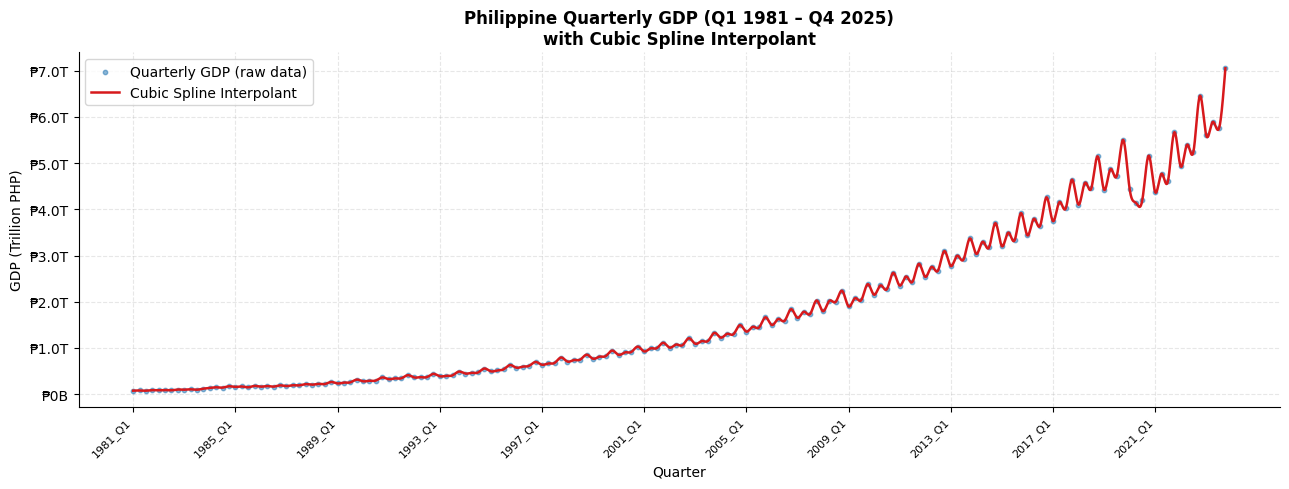

In [8]:
fig, ax = plt.subplots(figsize=(13, 5))

ax.scatter(t, y / 1e6, s=10, color="#2c7bb6", alpha=0.55, zorder=3,
           label="Quarterly GDP (raw data)")
ax.plot(t_fine, y_spline / 1e6, color="#d7191c", lw=1.8, zorder=4,
        label="Cubic Spline Interpolant")

ax.set_xticks(t[tick_idx])
ax.set_xticklabels(labels[tick_idx], rotation=45, ha="right", fontsize=8)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(
    lambda v, _: f"\u20b1{v:.1f}T" if v >= 1 else f"\u20b1{v*1000:.0f}B"))
ax.set_xlabel("Quarter")
ax.set_ylabel("GDP (Trillion PHP)")
ax.set_title("Philippine Quarterly GDP (Q1 1981 – Q4 2025)\nwith Cubic Spline Interpolant",
             fontweight="bold")
ax.legend(loc="upper left", fontsize=10)
ax.spines[["top", "right"]].set_visible(False)
ax.grid(True, ls="--", alpha=0.3)

fig.tight_layout()
fig.savefig("fig1_gdp_time_series.png", dpi=180, bbox_inches="tight")
plt.show()

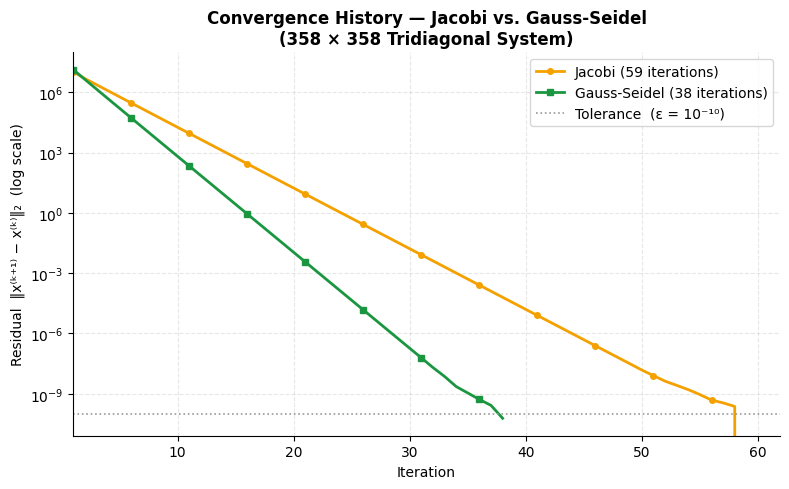

In [9]:
fig, ax = plt.subplots(figsize=(8, 5))

ax.semilogy(range(1, len(hist_j)  + 1), hist_j,
            color="#f4a100", lw=2, marker="o", markersize=4, markevery=5,
            label=f"Jacobi ({iters_j} iterations)")
ax.semilogy(range(1, len(hist_gs) + 1), hist_gs,
            color="#1a9641", lw=2, marker="s", markersize=4, markevery=5,
            label=f"Gauss-Seidel ({iters_gs} iterations)")
ax.axhline(1e-10, color="#999", ls=":", lw=1.2, label="Tolerance  (\u03b5 = 10\u207b\xb9\u2070)")

ax.set_xlim(left=1)
ax.set_xlabel("Iteration")
ax.set_ylabel("Residual  \u2016x\u207d\u1d4f\u207a\u00b9\u207e \u2212 x\u207d\u1d4f\u207e\u2016\u2082  (log scale)")
ax.set_title("Convergence History — Jacobi vs. Gauss-Seidel\n(358 \u00d7 358 Tridiagonal System)",
             fontweight="bold")
ax.legend(fontsize=10)
ax.spines[["top", "right"]].set_visible(False)
ax.grid(True, ls="--", alpha=0.3)

fig.tight_layout()
fig.savefig("fig2_convergence.png", dpi=180, bbox_inches="tight")
plt.show()

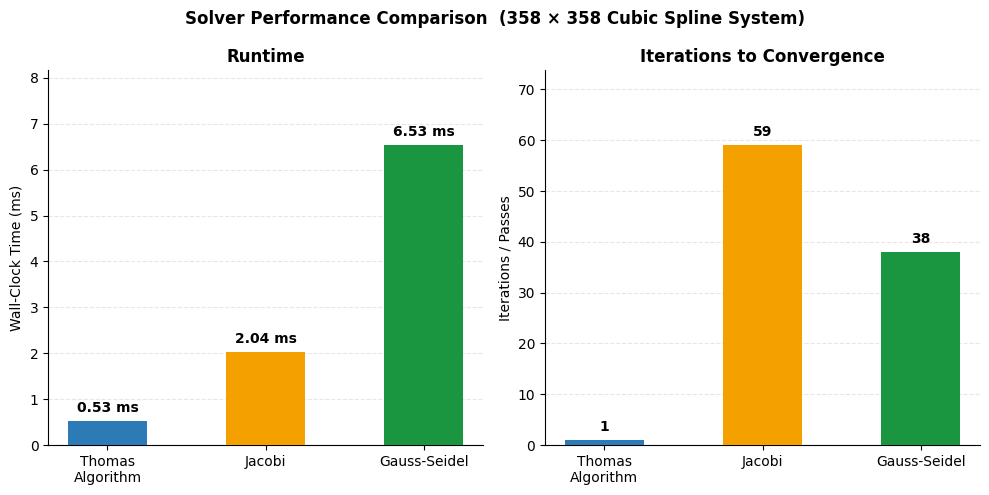

In [10]:
methods    = ["Thomas\nAlgorithm", "Jacobi", "Gauss-Seidel"]
runtimes   = [time_thomas, time_jacobi, time_gs]
iterations = [1, iters_j, iters_gs]
colors     = ["#2c7bb6", "#f4a100", "#1a9641"]

fig, (ax_left, ax_right) = plt.subplots(1, 2, figsize=(10, 5))

bars = ax_left.bar(methods, runtimes, color=colors, width=0.5, zorder=3)
for bar, val in zip(bars, runtimes):
    ax_left.text(bar.get_x() + bar.get_width() / 2,
                 bar.get_height() + max(runtimes) * 0.02,
                 f"{val:.2f} ms", ha="center", va="bottom",
                 fontsize=10, fontweight="bold")
ax_left.set_ylabel("Wall-Clock Time (ms)")
ax_left.set_title("Runtime", fontweight="bold")
ax_left.set_ylim(0, max(runtimes) * 1.25)
ax_left.spines[["top", "right"]].set_visible(False)
ax_left.grid(axis="y", ls="--", alpha=0.3)

bars2 = ax_right.bar(methods, iterations, color=colors, width=0.5, zorder=3)
for bar, val in zip(bars2, iterations):
    ax_right.text(bar.get_x() + bar.get_width() / 2,
                  bar.get_height() + max(iterations) * 0.02,
                  str(val), ha="center", va="bottom",
                  fontsize=10, fontweight="bold")
ax_right.set_ylabel("Iterations / Passes")
ax_right.set_title("Iterations to Convergence", fontweight="bold")
ax_right.set_ylim(0, max(iterations) * 1.25)
ax_right.spines[["top", "right"]].set_visible(False)
ax_right.grid(axis="y", ls="--", alpha=0.3)

fig.suptitle("Solver Performance Comparison  (358 \u00d7 358 Cubic Spline System)",
             fontweight="bold")
fig.tight_layout()
fig.savefig("fig3_solver_comparison.png", dpi=180, bbox_inches="tight")
plt.show()